# Phase 4: Model Evaluation & Analysis
AI-Powered Material Estimation System


In [2]:
import pandas as pd
import numpy as np
import random, math, colorsys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import *
from sklearn.dummy import DummyRegressor, DummyClassifier

np.random.seed(42)
random.seed(42)


In [4]:
def sqft_to_sqm(a): return a * 0.092903
def inch_to_meter(x): return x * 0.0254
def mm_to_meter(x): return x / 1000

def calculate_grout_volume(area, l, w, gw, th):
    area_sqm = sqft_to_sqm(area)
    l_m, w_m = inch_to_meter(l), inch_to_meter(w)
    gw_m, th_m = mm_to_meter(gw), mm_to_meter(th)
    vol = area_sqm * ((l_m+w_m)/(l_m*w_m)) * gw_m * th_m * 1.15
    return vol * 1_000_000

def grout_tubes(v): return math.ceil(v/330)

def min_grout_width(l):
    if l <= 10: return 1.5
    elif l <= 22: return 2
    elif l <= 32: return 2.5
    return 3

In [5]:

# Dataset Generation
areas = [100,500,1000,5000,10000,20000]
tiles = [4,6,8,10,12,16,24,32,48]

data=[]
for _ in range(200):
    area = random.choice(areas)
    l = random.choice(tiles)
    w = random.choice(tiles)
    th = random.uniform(6.4,13)

    gw = min_grout_width(l)
    vol = calculate_grout_volume(area,l,w,gw,th)

    data.append([
        area,l,w,th,
        math.ceil(area/100 * 200),
        vol, grout_tubes(vol),
        random.choice([0,1,2]),
        random.choice([0,1,2,3,4,5])
    ])

df = pd.DataFrame(data, columns=[
    "area","l","w","th",
    "clips","volume","tubes",
    "balanced","contrast"
])

In [6]:
# Train Models
X = df.drop(columns=["clips","volume","tubes","balanced","contrast"])
y_reg = df[["clips","volume","tubes"]]

X_train,X_test,y_train,y_test = train_test_split(X,y_reg,test_size=0.2,random_state=42)

rf_reg = RandomForestRegressor(n_estimators=200,max_depth=10)
rf_reg.fit(X_train,y_train)
pred = rf_reg.predict(X_test)

In [7]:

# Regression Evaluation
for i,col in enumerate(["clips","volume","tubes"]):
    y_true = y_test[col]
    y_pred = pred[:,i]
    print(col)
    print("MAE:",mean_absolute_error(y_true,y_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_true,y_pred)))
    print("R2:",r2_score(y_true,y_pred))
    print()

clips
MAE: 290.54372294372297
RMSE: 516.596000428099
R2: 0.9989183836203362

volume
MAE: 15966.963318260463
RMSE: 32406.27007513966
R2: 0.9245312879918879

tubes
MAE: 48.43429316829005
RMSE: 98.20648132841214
R2: 0.9245201729566687



In [8]:
# Classification
clf_results={}
for target in ["balanced","contrast"]:
    Xc_train,Xc_test,yc_train,yc_test = train_test_split(X,df[target],test_size=0.2)
    clf = RandomForestClassifier(n_estimators=200,class_weight="balanced")
    clf.fit(Xc_train,yc_train)
    yc_pred = clf.predict(Xc_test)
    clf_results[target]=(yc_test,yc_pred)

In [9]:
# Classification Evaluation
for name,(yt,yp) in clf_results.items():
    print(name)
    print("Accuracy:",accuracy_score(yt,yp))
    print("F1:",f1_score(yt,yp,average="macro"))
    print(classification_report(yt,yp))

balanced
Accuracy: 0.25
F1: 0.24991948470209338
              precision    recall  f1-score   support

           0       0.43      0.19      0.26        16
           1       0.23      0.21      0.22        14
           2       0.20      0.40      0.27        10

    accuracy                           0.25        40
   macro avg       0.29      0.27      0.25        40
weighted avg       0.30      0.25      0.25        40

contrast
Accuracy: 0.1
F1: 0.10119292472233649
              precision    recall  f1-score   support

           0       0.20      0.12      0.15         8
           1       0.17      0.20      0.18         5
           2       0.10      0.14      0.12         7
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         8
           5       0.20      0.12      0.15         8

    accuracy                           0.10        40
   macro avg       0.11      0.10      0.10        40
weighted avg       0.12      0.10   

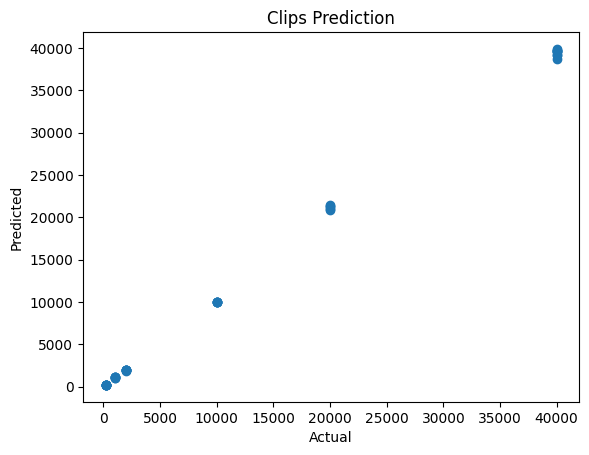

In [10]:
plt.scatter(y_test["clips"], pred[:,0])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Clips Prediction")
plt.show()

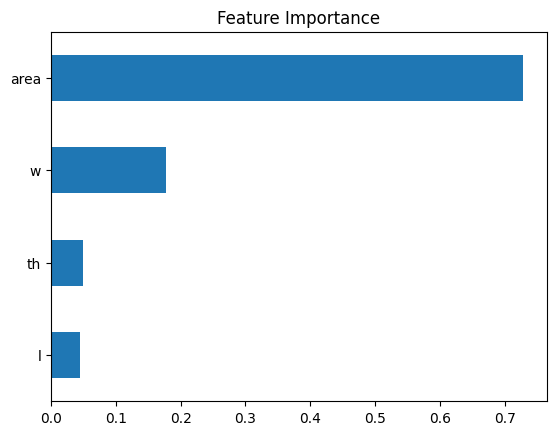

In [11]:
# Feature Importance
imp = pd.Series(rf_reg.feature_importances_, index=X.columns)
imp.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()